In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn

import matplotlib.pyplot as plt

In [2]:
ZPfile = Path('data/InstrumentZeroPoints.yaml')
with open(ZPfile, 'r') as f:
    ZeroPoint = yaml.safe_load(f)
wavs = ZeroPoint.keys()
ZeroPoint

{'452': 13.664362089856091,
 '548': 14.964690898633878,
 '652': 15.329155098901115,
 '747': 15.466755734095996,
 '852': 15.073233551565435}

In [3]:
def read_and_filter_data(calibration):
    data_file = f'data/{calibration.lower()}_snr_over_time.csv'
    t = Table.read(data_file, format='ascii.csv')
    # print(len(t))
    t = t[t['READSPED'] == 'regular']
    # print(len(t))
    t = t[t['MJD-OBS'] > 59750]
    # print(len(t))
    t = t[t['ELAPSED'] > 8]
    for wav in ['452', '548', '652', '747', '852']:
        t = t[t[f'SNRSC{wav}'] > 8]
        t = t[t[f'SNRCL{wav}'] > 8]   
    print(len(t))
    return t

In [4]:
def calculate_calibrator_magnitude(t, ZeroPoint):
    wavs = ZeroPoint.keys()
    for wav in wavs:
        # Magnitude in Science Trace
        magSC = ZeroPoint[wav] - np.log10(t[f'SNRSC{wav}']**2 / t['EXPTIME'])
        t.add_column(MaskedColumn(magSC, name=f'magSC{wav}'))
        t[f'SNRSC{wav}'].mask = t[f'SNRSC{wav}'].mask | (t[f'SNRSC{wav}'] <= 0)
        t[f'magSC{wav}'].mask = t[f'SNRSC{wav}'].mask
        # Magnitude in Calibration Trace
        magCL = ZeroPoint[wav] - np.log10(t[f'SNRCL{wav}']**2 / t['EXPTIME'])
        t.add_column(MaskedColumn(magCL, name=f'magCL{wav}'))
        t[f'SNRCL{wav}'].mask = t[f'SNRCL{wav}'].mask | (t[f'SNRCL{wav}'] <= 0)
        t[f'magCL{wav}'].mask = t[f'SNRCL{wav}'].mask
    return t

In [5]:
def plot_time_evolution_of_magnitude(t, calibration):
    # KPFERA 1.0 is before SM1
    SM1start = Time('2024-02-03')
    SM1end = Time('2024-02-23')
    # KPFERA 2.0 is between SM1 and SM2
    SM2start = Time('2024-10-31')
    SM2end = Time('2024-11-20')
    # KPFERA 2.5/2.6 is between SM2 and SM3
    SM3start = Time('2025-03-28')
    SM3end = Time('2025-04-23')
    # KPFERA 3.0 is between SM3 and SM4
    SM4start = Time('2025-08-31')
    SM4end = Time('2025-10-27')
    # KPFERA 4.0 is after SM4
    
    plt.figure(figsize=(10,6))
    
    plt.subplot(2,1,1)
    plt.title(f'Magnitude Evolution of the {calibration}')
    for w,wav in enumerate(wavs):
        color = ['b', 'c', 'g', 'y', 'r'][w]
        plt.plot(t['MJD-OBS'], t[f'magSC{wav}'], f'{color}o', alpha=0.3, ms=2, label=f'{wav}nm')
    plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
    plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
    plt.ylabel('Science Trace Mag')
    plt.grid()
    # plt.legend(loc='best')
    
    plt.subplot(2,1,2)
    for w,wav in enumerate(wavs):
        color = ['b', 'c', 'g', 'y', 'r'][w]
        plt.plot(t['MJD-OBS'], t[f'magCL{wav}'], f'{color}o', alpha=0.3, ms=2, label=f'{wav}nm')
    plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
    plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
    plt.xlabel('MJD')
    plt.ylabel('Cal Trace Mag')
    plt.grid()
    # plt.legend(loc='best')
    
    plt.show()

111256


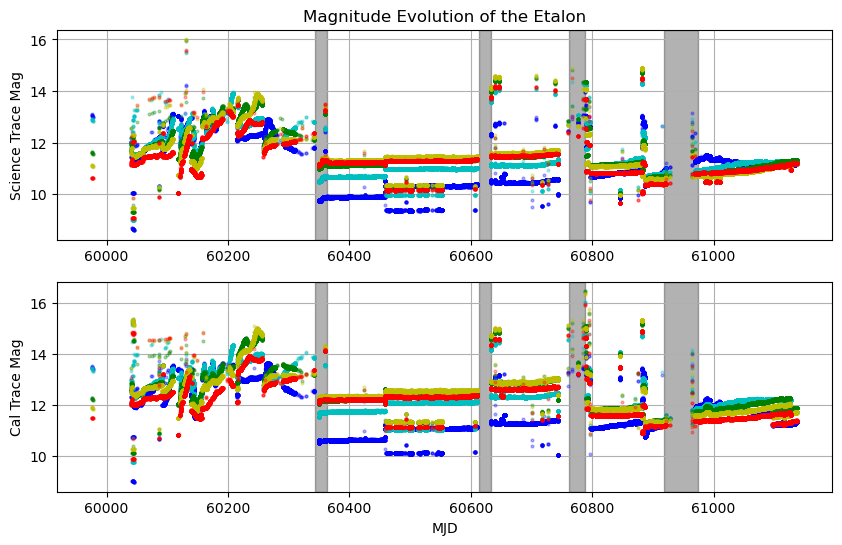

In [6]:
calibration = 'Etalon'
t = read_and_filter_data(calibration)
t = calculate_calibrator_magnitude(t, ZeroPoint)
plot_time_evolution_of_magnitude(t, calibration)

6024


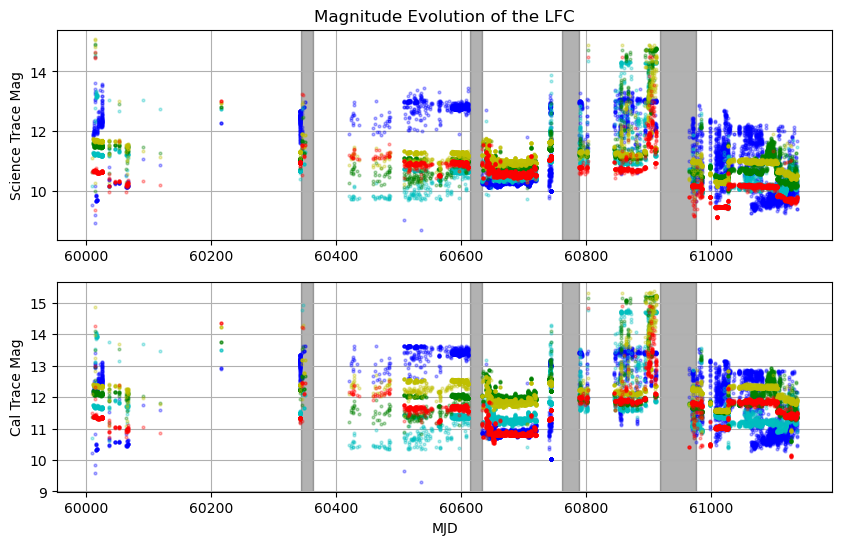

In [7]:
calibration = 'LFC'
t = read_and_filter_data(calibration)
t = calculate_calibrator_magnitude(t, ZeroPoint)
plot_time_evolution_of_magnitude(t, calibration)

18190


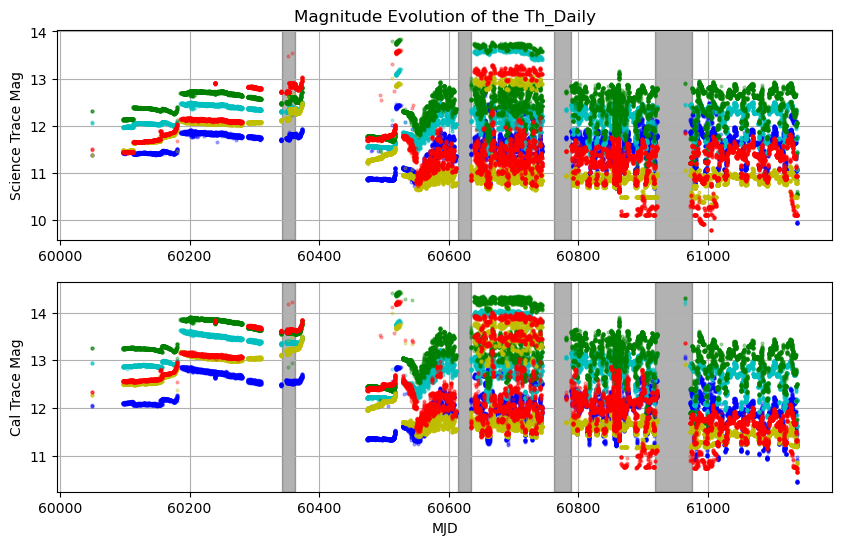

In [10]:
calibration = 'Th_Daily'
t = read_and_filter_data(calibration)
t = calculate_calibrator_magnitude(t, ZeroPoint)
plot_time_evolution_of_magnitude(t, calibration)